In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [3]:
car = pd.read_csv("car data.csv")
car.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
print("---- Dataset Information ---")
print(car.info())
print("\n---- Statistical Summary ---")
print(car.describe())
print("\n---- Missing Values ---")
print(car.isnull().sum())

---- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None

---- Statistical Summary ---
              Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.642584   38886.

In [5]:
#Feature engineering
car['car_age'] = 2024 - car['Year']
car.drop('Year', axis=1, inplace=True)
car.head()


,Car_Name,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,car_age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,10
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,11
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,7
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,13
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,10


In [6]:
for i in car.columns:
    if car[i].dtype == 'object':
        print(f"--- {i} ---")
        print(car[i].value_counts())
        print("\n")

--- Car_Name ---
Car_Name
city                        26
corolla altis               16
verna                       14
fortuner                    11
brio                        10
                            ..
Honda CB Trigger             1
Yamaha FZ S                  1
Bajaj Pulsar 135 LS          1
Activa 4g                    1
Bajaj Avenger Street 220     1
Name: count, Length: 98, dtype: int64


--- Fuel_Type ---
Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64


--- Selling_type ---
Selling_type
Dealer        195
Individual    106
Name: count, dtype: int64


--- Transmission ---
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64




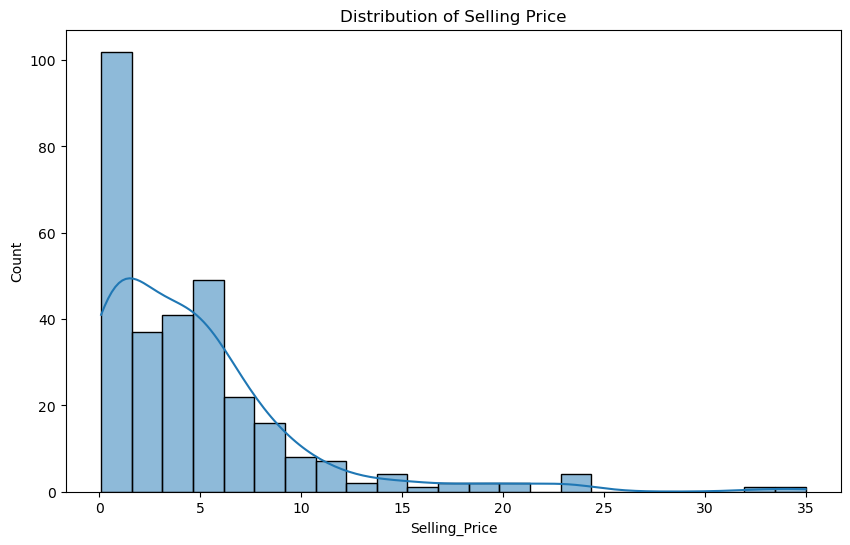

In [18]:
plt.figure(figsize=(10,6))
sns.histplot(car['Selling_Price'], kde=True)
plt.title('Distribution of Selling Price')
plt.savefig('selling_price_distribution.png')

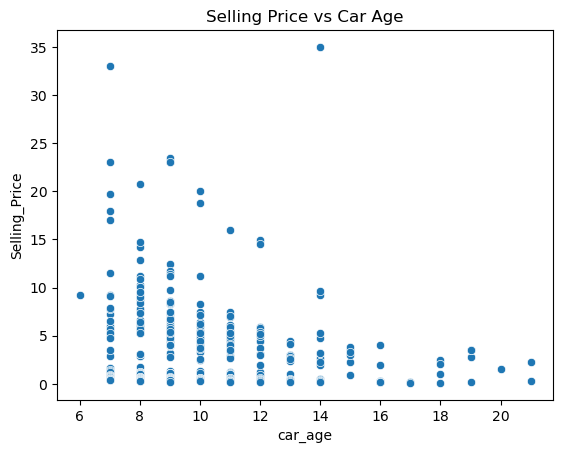

In [ ]:
plt.Figure(figsize=(10,6))
sns.scatterplot(x='car_age', y='Selling_Price', data=car)
plt.title('Selling Price vs Car Age')
plt.savefig('selling_price_vs_car_age.png')

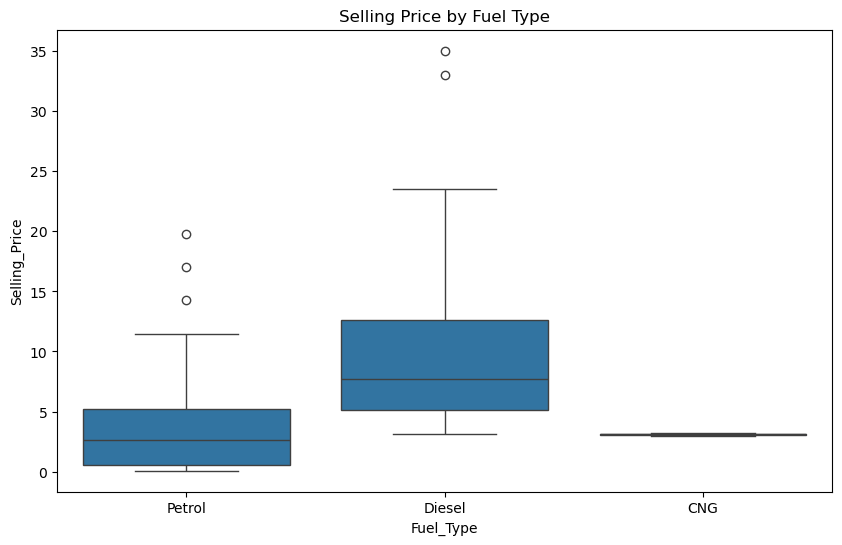

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x = 'Fuel_Type', y = 'Selling_Price', data=car)
plt.title('Selling Price by Fuel Type')
plt.savefig('selling_price_by_fuel_type.png')

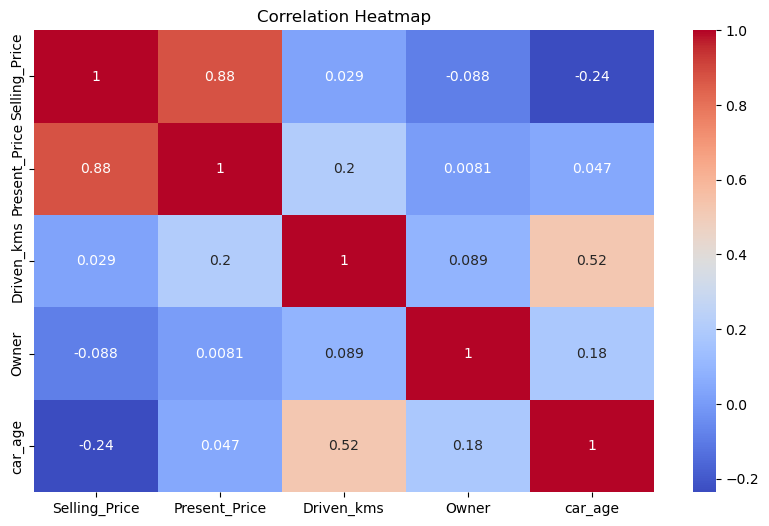

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(car.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png')

In [11]:
car.drop('Car_Name', axis=1, inplace=True)
car_encoded = pd.get_dummies(car, drop_first=True)
car_encoded.head()

,Selling_Price,Present_Price,Driven_kms,Owner,car_age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,10,False,True,False,True
1,4.75,9.54,43000,0,11,True,False,False,True
2,7.25,9.85,6900,0,7,False,True,False,True
3,2.85,4.15,5200,0,13,False,True,False,True
4,4.60,6.87,42450,0,10,True,False,False,True


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score   

x = car_encoded.drop('Selling_Price', axis=1)
y = car_encoded['Selling_Price']
x_train, x_test, y_train, y_test = train_test_split(x, y , random_state = 42, test_size = 0.2)
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [13]:
lr_pred = lr.predict(x_test)
print("Linear Regression Performance:")
print(f"MAE: {mean_absolute_error(y_test, lr_pred)}")
print(f"MSE: {mean_squared_error(y_test, lr_pred)}")
print(f"R² Score: {r2_score(y_test, lr_pred)}") 

Linear Regression Performance:
MAE: 1.2163740193330357
MSE: 3.4813498305118196
R² Score: 0.8488707839193153


In [14]:
rf = RandomForestRegressor(random_state=42)
rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)

In [15]:
print("Performance of Random Forest:")
print(f"MAE: {mean_absolute_error(y_test, rf_pred)}")
print(f"MSE: {mean_squared_error(y_test, rf_pred)}")
print(f"R² Score: {r2_score(y_test, rf_pred)}") 

Performance of Random Forest:
MAE: 0.6368655737704919
MSE: 0.9339387986885236
R² Score: 0.9594566919773236


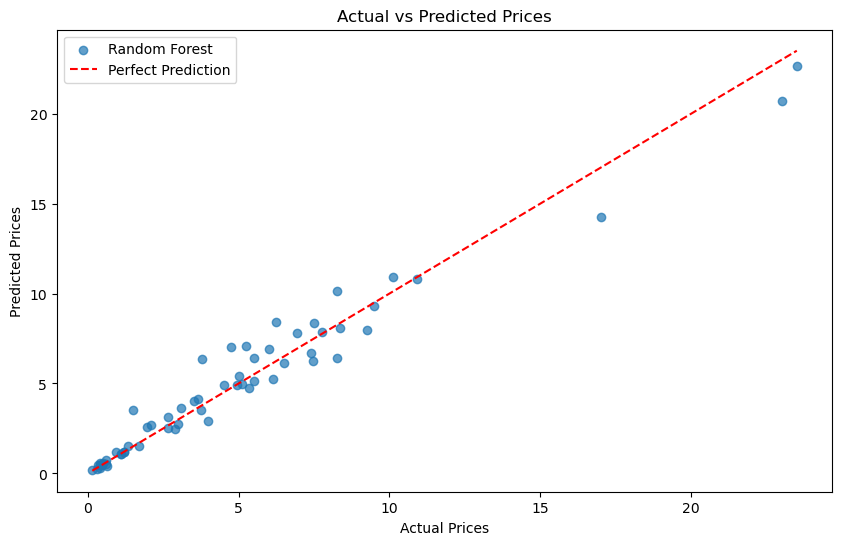

In [21]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, rf_pred, label='Random Forest', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.legend()
plt.savefig('rf_actual_vs_predicted_prices.png')

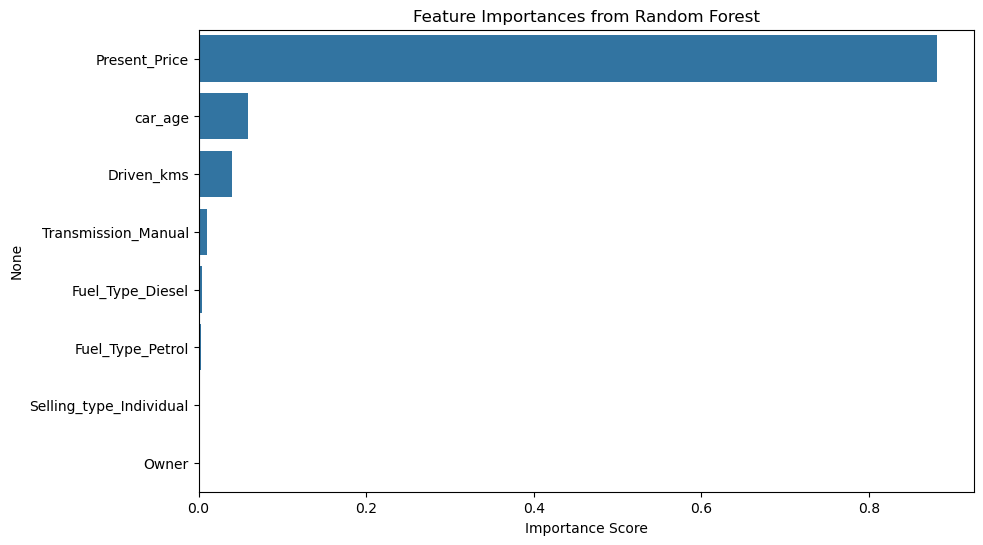

In [22]:

feature_importances = pd.Series(rf.feature_importances_, index=x.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=feature_importances.values, y=feature_importances.index)
plt.title('Feature Importances from Random Forest')
plt.xlabel('Importance Score')    
plt.savefig('rf_feature_importances.png')  